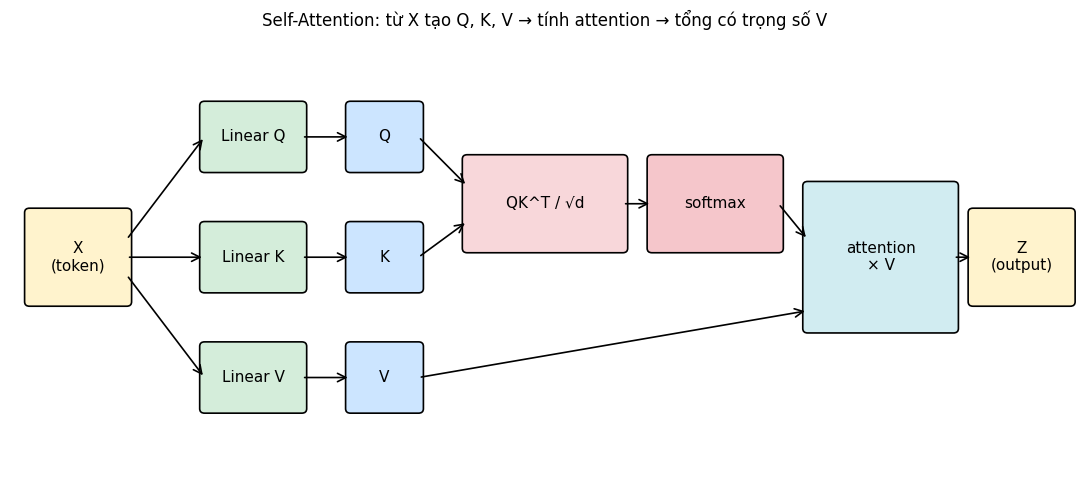

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 11); ax.set_ylim(0, 5); ax.axis('off')

def box(x, y, w, h, text, color='#cce5ff'):
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                       facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=11)

def arrow(x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->',
                        mutation_scale=15, color='black', linewidth=1.2)
    ax.add_patch(a)

# Input X
box(0.2, 2.0, 1.0, 1.0, 'X\n(token)', '#fff3cd')

# Three projections
box(2.0, 3.5, 1.0, 0.7, 'Linear Q', '#d4edda')
box(2.0, 2.15, 1.0, 0.7, 'Linear K', '#d4edda')
box(2.0, 0.8, 1.0, 0.7, 'Linear V', '#d4edda')
arrow(1.2, 2.7, 2.0, 3.85); arrow(1.2, 2.5, 2.0, 2.5); arrow(1.2, 2.3, 2.0, 1.15)

# Q, K, V
box(3.5, 3.5, 0.7, 0.7, 'Q', '#cce5ff')
box(3.5, 2.15, 0.7, 0.7, 'K', '#cce5ff')
box(3.5, 0.8, 0.7, 0.7, 'V', '#cce5ff')
arrow(3.0, 3.85, 3.5, 3.85); arrow(3.0, 2.5, 3.5, 2.5); arrow(3.0, 1.15, 3.5, 1.15)

# QK^T / sqrt(d)
box(4.7, 2.6, 1.6, 1.0, 'QK^T / \u221ad', '#f8d7da')
arrow(4.2, 3.85, 4.7, 3.3); arrow(4.2, 2.5, 4.7, 2.9)

# Softmax
box(6.6, 2.6, 1.3, 1.0, 'softmax', '#f5c6cb')
arrow(6.3, 3.1, 6.6, 3.1)

# Multiply with V
box(8.2, 1.7, 1.5, 1.6, 'attention\n× V', '#d1ecf1')
arrow(7.9, 3.1, 8.2, 2.7); arrow(4.2, 1.15, 8.2, 1.9)

# Output
box(9.9, 2.0, 1.0, 1.0, 'Z\n(output)', '#fff3cd')
arrow(9.7, 2.5, 9.9, 2.5)

ax.set_title('Self-Attention: từ X tạo Q, K, V → tính attention → tổng có trọng số V', fontsize=12)
plt.tight_layout(); plt.show()

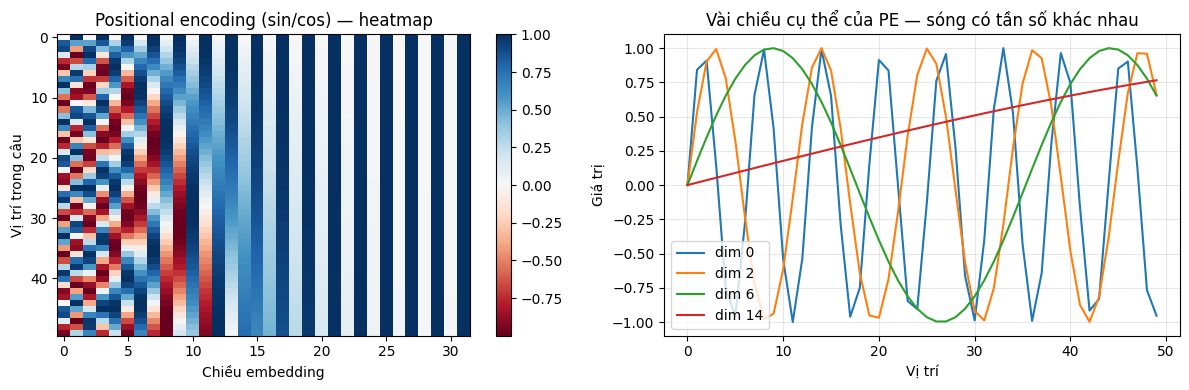

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sinusoidal positional encoding như trong paper gốc.
seq_len, d_model = 50, 32
pe = np.zeros((seq_len, d_model))
for pos in range(seq_len):
    for i in range(0, d_model, 2):
        pe[pos, i]   = np.sin(pos / 10000 ** (i / d_model))
        pe[pos, i+1] = np.cos(pos / 10000 ** (i / d_model))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap toàn bộ
im = axes[0].imshow(pe, aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Chiều embedding'); axes[0].set_ylabel('Vị trí trong câu')
axes[0].set_title('Positional encoding (sin/cos) — heatmap')
plt.colorbar(im, ax=axes[0])

# Vài chiều cụ thể
for d in [0, 2, 6, 14]:
    axes[1].plot(pe[:, d], label=f'dim {d}')
axes[1].set_xlabel('Vị trí'); axes[1].set_ylabel('Giá trị')
axes[1].set_title('Vài chiều cụ thể của PE — sóng có tần số khác nhau')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


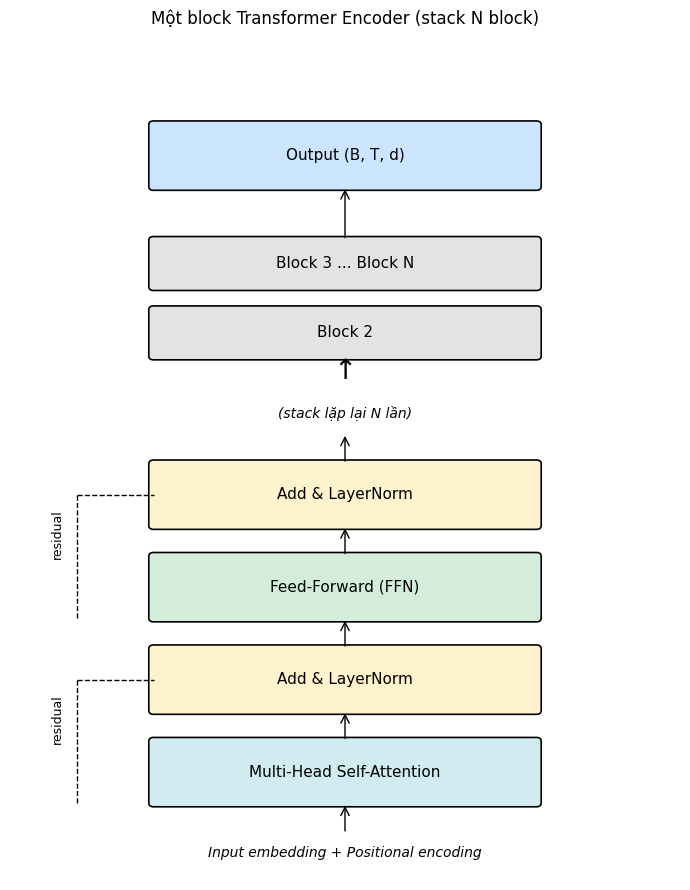

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7, 9))
ax.set_xlim(0, 7); ax.set_ylim(0, 11); ax.axis('off')

def block(y, text, color, h=0.8):
    p = FancyBboxPatch((1.5, y), 4, h, boxstyle='round,pad=0.05',
                       facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(p)
    ax.text(3.5, y + h/2, text, ha='center', va='center', fontsize=11)

def arrow(y1, y2):
    ax.add_patch(FancyArrowPatch((3.5, y1), (3.5, y2), arrowstyle='->',
                                 mutation_scale=15, color='black'))

def residual(y_start, y_end):
    ax.plot([0.7, 0.7], [y_start, y_end], 'k--', linewidth=1)
    ax.plot([0.7, 1.5], [y_end, y_end], 'k--', linewidth=1)
    ax.text(0.5, (y_start + y_end)/2, 'residual', rotation=90, fontsize=9, ha='center')

# Bottom up
ax.text(3.5, 0.3, 'Input embedding + Positional encoding', ha='center', fontsize=10, style='italic')
arrow(0.6, 1.0)

block(1.0, 'Multi-Head Self-Attention', '#d1ecf1')
arrow(1.8, 2.2)
block(2.2, 'Add & LayerNorm', '#fff3cd')
arrow(3.0, 3.4)
residual(1.0, 2.6)

block(3.4, 'Feed-Forward (FFN)', '#d4edda')
arrow(4.2, 4.6)
block(4.6, 'Add & LayerNorm', '#fff3cd')
arrow(5.4, 5.8)
residual(3.4, 5.0)

ax.text(3.5, 6.0, '(stack lặp lại N lần)', ha='center', fontsize=10, style='italic')
ax.text(3.5, 6.5, '↑', ha='center', fontsize=20)
block(6.8, 'Block 2', '#e2e3e5', h=0.6)
block(7.7, 'Block 3 ... Block N', '#e2e3e5', h=0.6)
arrow(8.3, 9.0)
block(9.0, 'Output (B, T, d)', '#cce5ff')

ax.set_title('Một block Transformer Encoder (stack N block)', fontsize=12)
plt.tight_layout(); plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, return_attn=False):
        # x: (batch, seq_len, embed_dim)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Tính ma trận tương đồng. transpose(-2, -1) đổi 2 chiều cuối.
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.embed_dim)
        attn = F.softmax(scores, dim=-1)             # (batch, seq_len, seq_len)
        out = attn @ V                               # (batch, seq_len, embed_dim)

        if return_attn:
            return out, attn
        return out

# Test trên một câu giả lập 5 token, mỗi token là vector 8 chiều.
sa = SelfAttention(embed_dim=8)
x = torch.randn(1, 5, 8)
out, attn = sa(x, return_attn=True)
print('Input shape :', x.shape)
print('Output shape:', out.shape)
print('Attn shape  :', attn.shape, '  (mỗi token ↔ mỗi token)')
print('Attn[0]     =\n', attn[0])
print('Tổng mỗi hàng (phải = 1):', attn[0].sum(dim=-1))

Input shape : torch.Size([1, 5, 8])
Output shape: torch.Size([1, 5, 8])
Attn shape  : torch.Size([1, 5, 5])   (mỗi token ↔ mỗi token)
Attn[0]     =
 tensor([[0.3571, 0.1273, 0.2532, 0.2217, 0.0407],
        [0.2283, 0.1779, 0.2365, 0.1824, 0.1750],
        [0.0857, 0.1879, 0.2146, 0.1882, 0.3236],
        [0.1231, 0.1535, 0.2547, 0.1542, 0.3146],
        [0.2047, 0.2722, 0.0709, 0.1445, 0.3076]], grad_fn=<SelectBackward0>)
Tổng mỗi hàng (phải = 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)


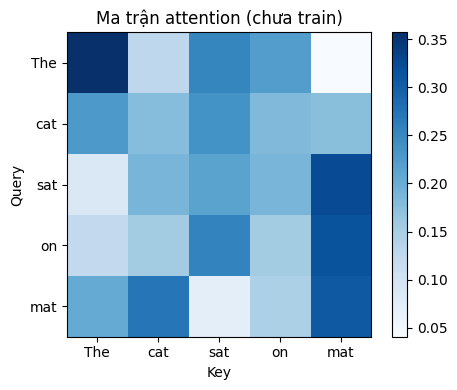

In [10]:
tokens = ['The', 'cat', 'sat', 'on', 'mat']
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attn[0].detach().numpy(), cmap='Blues')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(tokens); ax.set_yticklabels(tokens)
ax.set_xlabel('Key'); ax.set_ylabel('Query')
ax.set_title('Ma trận attention (chưa train)')
plt.colorbar(im); plt.tight_layout(); plt.show()

In [11]:
# Mở rộng vocab và data so với bài LSTM, để có đủ tín hiệu.
from torch.nn.utils.rnn import pad_sequence

vocab = {'': 0, 'i': 1, 'you': 2, 'he': 3, 'we': 4, 'they': 5,
         'love': 6, 'like': 7, 'enjoy': 8, 'hate': 9, 'dislike': 10,
         'this': 11, 'that': 12, 'movie': 13, 'song': 14, 'food': 15,
         'place': 16, 'good': 17, 'bad': 18, 'great': 19, 'awful': 20,
         'not': 21, 'is': 22, 'so': 23, 'really': 24}

raw_data = [
    ('i love this movie',         1),
    ('we enjoy that song',         1),
    ('this food is great',         1),
    ('he likes the place',         1),  # không có 'the' trong vocab — bỏ qua khi encode
    ('they really love this',      1),
    ('i hate that movie',          0),
    ('this song is bad',           0),
    ('we dislike that food',       0),
    ('he is not good',             0),
    ('that place is awful',        0),
    ('this movie is so good',      1),
    ('i really enjoy this',        1),
    ('they hate this place',       0),
    ('that food is not great',     0),
    ('we love this song',          1),
    ('i dislike that movie',       0),
]

def encode(s):
    return [vocab[w] for w in s.lower().split() if w in vocab]

seqs   = [torch.tensor(encode(s), dtype=torch.long) for s, _ in raw_data]
labels = torch.tensor([y for _, y in raw_data], dtype=torch.long)
lengths = torch.tensor([len(s) for s in seqs])
X = pad_sequence(seqs, batch_first=True, padding_value=0)   # (N, max_len)
print('X shape:', X.shape, ' labels shape:', labels.shape)

X shape: torch.Size([16, 5])  labels shape: torch.Size([16])


In [12]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=4, ffn_dim=64,
                 num_layers=2, num_classes=2, max_len=20):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Positional embedding học được — đơn giản hơn sin/cos, dùng cho seq ngắn.
        self.pos_emb   = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ffn_dim, dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, src_key_padding_mask=None):
        # x: (B, T)
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        emb = self.token_emb(x) + self.pos_emb(positions)
        # padding mask: True ở vị trí padding để Transformer bỏ qua.
        out = self.encoder(emb, src_key_padding_mask=src_key_padding_mask)
        # Lấy trung bình theo seq dimension (loại bỏ vị trí padding khi tính trung bình).
        if src_key_padding_mask is not None:
            mask = (~src_key_padding_mask).float().unsqueeze(-1)
            pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = out.mean(dim=1)
        return self.fc(pooled)

model = TransformerClassifier(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {n_params:,}')

Tổng tham số: 18,594


Epoch  40  loss = 0.0262  acc = 100.00%
Epoch  80  loss = 0.0035  acc = 100.00%
Epoch 120  loss = 0.0023  acc = 100.00%
Epoch 160  loss = 0.0016  acc = 100.00%
Epoch 200  loss = 0.0013  acc = 100.00%


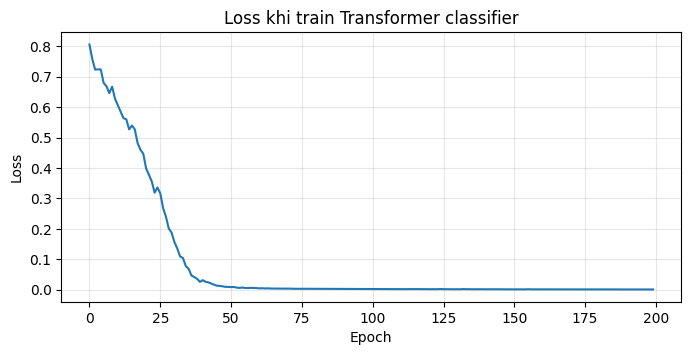

In [13]:
X, labels = X.to(device), labels.to(device)
padding_mask = (X == 0)   # True ở chỗ padding

loss_history = []
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    logits = model(X, src_key_padding_mask=padding_mask)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 40 == 0:
        acc = (logits.argmax(1) == labels).float().mean().item()
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}  acc = {acc*100:.2f}%')

plt.figure(figsize=(8, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train Transformer classifier'); plt.show()

In [14]:
# Predict trên câu KHÔNG có trong train.
model.eval()
test_sentences = [
    'we enjoy this song',
    'this movie is awful',
    'i hate that food',
    'they really like that place',
    'this is not good',
]
for s in test_sentences:
    ids = encode(s)
    seq = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    mask = (seq == 0)
    with torch.no_grad():
        logits = model(seq, src_key_padding_mask=mask)
        prob = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    label = 'Tích cực' if prob[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:30s}"  →  {label}  (P_pos = {prob[1]:.2f})')

"we enjoy this song            "  →  Tích cực  (P_pos = 1.00)
"this movie is awful           "  →  Tiêu cực  (P_pos = 0.01)
"i hate that food              "  →  Tiêu cực  (P_pos = 0.00)
"they really like that place   "  →  Tích cực  (P_pos = 0.98)
"this is not good              "  →  Tiêu cực  (P_pos = 0.01)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Bài1

In [15]:
import random

# 1. Generate Dataset
vocab_ex1 = ['', 'the', 'a', 'cat', 'dog', 'is', 'was', 'good', 'bad', 'very']
word2id = {w: i for i, w in enumerate(vocab_ex1)}

def generate_data(n=200, seq_len=8):
    data = []
    for _ in range(n):
        # Randomly choose words from vocab (excluding padding at index 0)
        seq = [random.choice(vocab_ex1[1:]) for _ in range(seq_len)]
        label = 1 if 'good' in seq else 0
        ids = [word2id[w] for w in seq]
        data.append((torch.tensor(ids), torch.tensor(label)))
    return data

train_data = generate_data(200)
X_ex1 = torch.stack([d[0] for d in train_data]).to(device)
Y_ex1 = torch.stack([d[1] for d in train_data]).to(device)

# 2. Build Model using our SelfAttention class
class SimpleAttnClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attn = SelfAttention(embed_dim)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        # x: (B, T)
        emb = self.embedding(x)                 # (B, T, D)
        out, weights = self.attn(emb, return_attn=True)
        # Global Average Pooling over time dimension
        pooled = out.mean(dim=1)
        return self.fc(pooled), weights

model_ex1 = SimpleAttnClassifier(len(vocab_ex1)).to(device)
opt_ex1 = torch.optim.Adam(model_ex1.parameters(), lr=0.01)
crit_ex1 = nn.CrossEntropyLoss()

# 3. Training Loop
for epoch in range(100):
    logits, _ = model_ex1(X_ex1)
    loss = crit_ex1(logits, Y_ex1)
    opt_ex1.zero_grad()
    loss.backward()
    opt_ex1.step()
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 20, Loss: 0.0275
Epoch 40, Loss: 0.0001
Epoch 60, Loss: 0.0000
Epoch 80, Loss: 0.0000
Epoch 100, Loss: 0.0000


Sentence: the cat is very good dog was a
Prediction: Positive (Prob: 1.00)


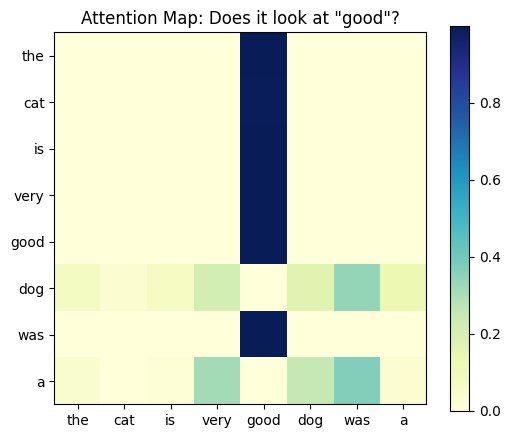

In [16]:
# 4. Visualization
model_ex1.eval()
test_seq_str = ['the', 'cat', 'is', 'very', 'good', 'dog', 'was', 'a']
test_ids = torch.tensor([[word2id[w] for w in test_seq_str]]).to(device)

with torch.no_grad():
    logits, attn_weights = model_ex1(test_ids)
    prob = F.softmax(logits, dim=1)

print(f'Sentence: {" ".join(test_seq_str)}')
print(f'Prediction: {"Positive" if prob[0,1] > 0.5 else "Negative"} (Prob: {prob[0,1]:.2f})')

# Plot Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights[0].cpu().numpy(), cmap='YlGnBu')
ax.set_xticks(range(8)); ax.set_yticks(range(8))
ax.set_xticklabels(test_seq_str); ax.set_yticklabels(test_seq_str)
plt.title('Attention Map: Does it look at "good"?')
plt.colorbar(im); plt.show()

Bài 2

In [17]:
import time
import random

# 1. Generate Long-Dependency Data
vocab_ex2 = 'abcdefghij' # 10 characters
char2id = {c: i for i, c in enumerate(vocab_ex2)}

def generate_long_dep_data(n=1000, seq_len=30):
    X, Y = [], []
    for _ in range(n):
        seq = [random.choice(vocab_ex2) for _ in range(seq_len)]
        X.append([char2id[c] for c in seq])
        Y.append(char2id[seq[0]]) # Label is the first character
    return torch.tensor(X), torch.tensor(Y)

X_train_ex2, Y_train_ex2 = generate_long_dep_data(1000)
X_test_ex2, Y_test_ex2 = generate_long_dep_data(200)

# 2. Build Transformer Classifier
class TransformerLongDep(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, nhead=4, nlayers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Parameter(torch.zeros(1, 30, embed_dim))
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=nlayers)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x) + self.pos_emb
        x = self.transformer(x)
        return self.fc(x.mean(dim=1)) # Global average pooling

model_ex2 = TransformerLongDep(len(vocab_ex2)).to(device)
optimizer_ex2 = torch.optim.Adam(model_ex2.parameters(), lr=0.001)
criterion_ex2 = nn.CrossEntropyLoss()

# 3. Training Loop with timing
epochs = 50
batch_size = 64
start_time = time.time()

for epoch in range(epochs):
    model_ex2.train()
    indices = torch.randperm(X_train_ex2.size(0))
    for i in range(0, X_train_ex2.size(0), batch_size):
        idx = indices[i:i+batch_size]
        bx, by = X_train_ex2[idx].to(device), Y_train_ex2[idx].to(device)

        logits = model_ex2(bx)
        loss = criterion_ex2(logits, by)

        optimizer_ex2.zero_grad()
        loss.backward()
        optimizer_ex2.step()

end_time = time.time()
total_time = end_time - start_time
print(f'Finished training in {total_time:.2f}s ({total_time/epochs:.4f}s/epoch)')

# 4. Evaluation
model_ex2.eval()
with torch.no_grad():
    test_logits = model_ex2(X_test_ex2.to(device))
    acc = (test_logits.argmax(1) == Y_test_ex2.to(device)).float().mean()
    print(f'Test Accuracy: {acc.item()*100:.2f}%')

Finished training in 5.17s (0.1033s/epoch)
Test Accuracy: 100.00%


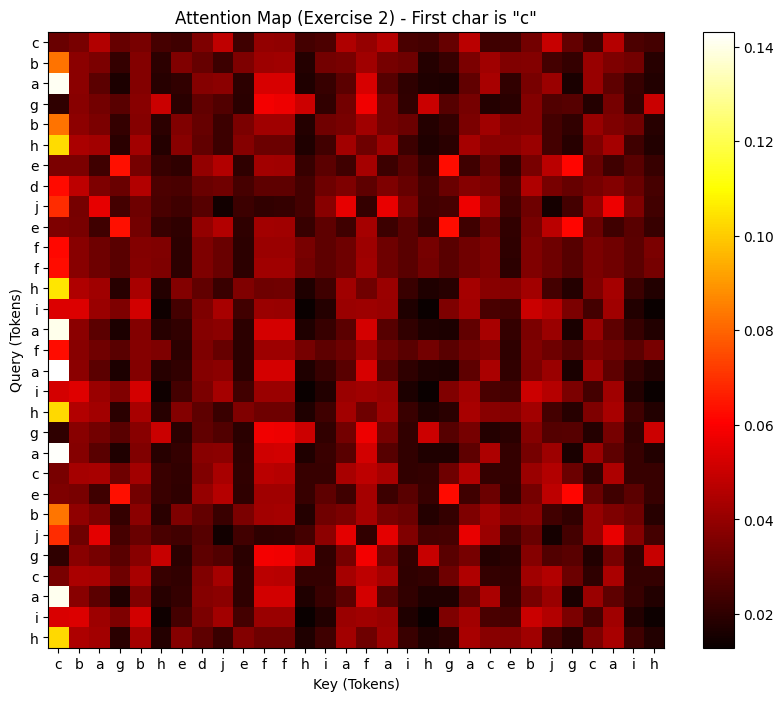

In [18]:
model_ex2.eval()
# 1. Get a sample from the test set
sample_idx = 0
test_sample = X_test_ex2[sample_idx:sample_idx+1].to(device)
test_label = Y_test_ex2[sample_idx].item()
char_sequence = [vocab_ex2[i] for i in test_sample[0]]

# 2. To get attention weights, we need to access the internal MultiheadAttention layer.
# nn.TransformerEncoder doesn't return weights directly easily without hooks or manual forward.
# Let's perform a manual forward through the first layer to extract weights.
with torch.no_grad():
    emb = model_ex2.embedding(test_sample) + model_ex2.pos_emb
    # Access the first layer of the encoder
    layer = model_ex2.transformer.layers[0]
    # MultiheadAttention forward returns (output, weights)
    _, weights = layer.self_attn(emb, emb, emb, need_weights=True)

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 8))
# weights shape is (batch, L, L). We take the first one.
im = ax.imshow(weights[0].cpu().numpy(), cmap='hot')
ax.set_xticks(range(30)); ax.set_yticks(range(30))
ax.set_xticklabels(char_sequence); ax.set_yticklabels(char_sequence)
ax.set_xlabel('Key (Tokens)'); ax.set_ylabel('Query (Tokens)')
plt.title(f'Attention Map (Exercise 2) - First char is "{vocab_ex2[test_label]}"')
plt.colorbar(im)
plt.show()

Bài 3

In [24]:
!pip install -q -U transformers datasets accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.8 MB/s eta 0:00:00


In [26]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np

# 1. Load a small subset of IMDB for speed
# Using full path 'stanfordnlp/imdb' to avoid HfUriError bug in library resolution
dataset = load_dataset("stanfordnlp/imdb")
train_ds = dataset['train'].shuffle(seed=42).select(range(1000))
test_ds = dataset['test'].shuffle(seed=42).select(range(200))

# 2. Tokenize
model_ckpt = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True)

tokenized_train = train_ds.map(tokenize_fn, batched=True)
tokenized_test = test_ds.map(tokenize_fn, batched=True)

# 3. Load Model
model_bert = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2).to(device)

# 4. Define Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    eval_strategy='epoch',
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to='none'
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': (predictions == labels).mean()}

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# 5. Fine-tune
trainer.train()

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.345673,0.860000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.46496560668945314, metrics={'train_runtime': 58.3445, 'train_samples_per_second': 17.14, 'train_steps_per_second': 2.142, 'total_flos': 132467398656000.0, 'train_loss': 0.46496560668945314, 'epoch': 1.0})

In [27]:
# 6. Predict examples
examples = [
    'This movie was an absolute masterpiece with great acting.',
    'I hated every minute of this film, it was a waste of time.',
    'The plot was somewhat predictable but the visuals were stunning.',
    'A boring and uninspired story that fails to capture the audience.',
    'Surprisingly good! I enjoyed the character development.'
]

model_bert.eval()
for text in examples:
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model_bert(**inputs).logits
    pred = torch.argmax(logits, dim=-1).item()
    sentiment = 'Positive' if pred == 1 else 'Negative'
    print(f'"{text}" -> {sentiment}')

"This movie was an absolute masterpiece with great acting." -> Positive
"I hated every minute of this film, it was a waste of time." -> Negative
"The plot was somewhat predictable but the visuals were stunning." -> Positive
"A boring and uninspired story that fails to capture the audience." -> Negative
"Surprisingly good! I enjoyed the character development." -> Positive
